In [12]:
# Network-Level Functional Connectivity Analysis in Autism Spectrum Disorder: A Resting-State fMRI Study.

In [13]:
import nilearn
import warnings
warnings.filterwarnings("ignore")

In [14]:
from nilearn.datasets import fetch_abide_pcp
# Fetch the full data and update phenotypic data and cross_validation
abide = fetch_abide_pcp(derivatives = ['func_preproc'], pipeline = 'cpac', quality_checked = True)

[get_dataset_dir] Dataset found in C:\Users\mutlu\nilearn_data\ABIDE_pcp

In [15]:
from nilearn.datasets import fetch_abide_pcp
import pandas as pd

# Derivatives = preprocessed data
# Pipeline = CPAC (motion correction, slice timing, normalization to MNI space, nuisance regression)
# Quality Checked = True (only good quality scans included)
abide = fetch_abide_pcp(derivatives=['func_preproc'], pipeline='cpac', quality_checked=True)

func_imgs = abide.func_preproc
df = pd.DataFrame(abide.phenotypic).reset_index(drop=True)

#ensuring the numbers of ASD and control
asd_indices = df.index[df["DX_GROUP"] == 1].tolist()
control_indices = df.index[df["DX_GROUP"] == 2].tolist()

print(f"ASD subjects: {len(asd_indices)}")
print(f"Control subjects: {len(control_indices)}")

[get_dataset_dir] Dataset found in C:\Users\mutlu\nilearn_data\ABIDE_pcp

ASD subjects: 403
Control subjects: 468


In [16]:
from nilearn import datasets

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7, resolution_mm=2)
labels = [lbl.decode("utf-8") for lbl in atlas["labels"]]

# DMN regions are the ones labeled "Default" in the Schaefer/Yeo 7-network scheme
dmn_indices = [i for i, name in enumerate(labels) if "Default" in name]
dmn_labels = [labels[i] for i in dmn_indices]

# The DMN labelled regions from the atlas are the regions I analyzed
print(f"Number of DMN regions: {len(dmn_indices)}")
for dmn_label in dmn_labels:
    print(dmn_label)

[get_dataset_dir] Dataset found in C:\Users\mutlu\nilearn_data\schaefer_2018

Number of DMN regions: 46
7Networks_LH_Default_Temp_1
7Networks_LH_Default_Temp_2
7Networks_LH_Default_Temp_3
7Networks_LH_Default_Temp_4
7Networks_LH_Default_Temp_5
7Networks_LH_Default_Par_1
7Networks_LH_Default_Par_2
7Networks_LH_Default_Par_3
7Networks_LH_Default_Par_4
7Networks_LH_Default_PFC_1
7Networks_LH_Default_PFC_2
7Networks_LH_Default_PFC_3
7Networks_LH_Default_PFC_4
7Networks_LH_Default_PFC_5
7Networks_LH_Default_PFC_6
7Networks_LH_Default_PFC_7
7Networks_LH_Default_PFC_8
7Networks_LH_Default_PFC_9
7Networks_LH_Default_PFC_10
7Networks_LH_Default_PFC_11
7Networks_LH_Default_PFC_12
7Networks_LH_Default_PFC_13
7Networks_LH_Default_pCunPCC_1
7Networks_LH_Default_pCunPCC_2
7Networks_LH_Default_pCunPCC_3
7Networks_LH_Default_pCunPCC_4
7Networks_LH_Default_PHC_1
7Networks_RH_Default_Par_1
7Networks_RH_Default_Par_2
7Networks_RH_Default_Par_3
7Networks_RH_Default_Temp_1
7Networks_RH_Default_Temp_2
7Networks_RH_Default_Temp_3
7Networks_RH_Default_Temp_4
7Networks_RH_Default_Temp_5

In [17]:
import os
import numpy as np

# --------------------------------------------------------------------
# STEP 1: Full-brain extraction (200 regions)
# --------------------------------------------------------------------
# Each subject's preprocessed fMRI scan was passed through a NiftiLabelsMasker
# built on the Schaefer 2018 atlas (200 ROIs, 7 Yeo networks). This produced
# one (timepoints x 200) time-series array per subject, saved to
# TS_200ROI_ASD_simple/ and TS_200ROI_CONTROL_simple/. Loading those results
# here rather than re-running extraction.

def load_timeseries(folder):
    files = sorted(os.listdir(folder), key=lambda x: int(x.split('_')[1].split('.')[0]))
    return [np.load(os.path.join(folder, f)) for f in files], files

asd_200roi, asd_files = load_timeseries("TS_200ROI_ASD_simple")
control_200roi, control_files = load_timeseries("TS_200ROI_CONTROL_simple")

print(f"ASD subjects (200-ROI): {len(asd_200roi)}")
print(f"Control subjects (200-ROI): {len(control_200roi)}")
print(f"Example shape: {asd_200roi[0].shape}" + " for this example subjects, (timepoint, 200) since 200 regions are extracted")  # (timepoints, 200)


# --------------------------------------------------------------------
# STEP 2: DMN subsetting (200 -> 46 regions)
# --------------------------------------------------------------------
# From the 200 whole-brain regions, only the 46 labeled "Default" (the
# Default Mode Network, per the Yeo 7-network scheme) were kept. This
# subsetting was already applied and saved to DMN_ASD/ and DMN_CONTROL/.
# Loading those directly here.

asd_dmn, _ = load_timeseries("DMN_ASD")
control_dmn, _ = load_timeseries("DMN_CONTROL")

print(f"\nASD subjects (DMN, 46 regions): {len(asd_dmn)}")
print(f"Control subjects (DMN, 46 regions): {len(control_dmn)}")
print(f"Example shape: {asd_dmn[0].shape}" + " for this example subjects, (timepoint, 46) since 46 DMN regions are extracted only")  # (timepoints, 46)

ASD subjects (200-ROI): 403
Control subjects (200-ROI): 468
Example shape: (196, 200) for this example subjects, (timepoint, 200) since 200 regions are extracted

ASD subjects (DMN, 46 regions): 403
Control subjects (DMN, 46 regions): 468
Example shape: (196, 46) for this example subjects, (timepoint, 46) since 46 DMN regions are extracted only


In [18]:
from nilearn.connectome import ConnectivityMeasure

# --------------------------------------------------------------------
# How the connectivity vectors were built (already run, shown for reference)
# --------------------------------------------------------------------
# Each subject's (timepoints, 46) DMN time-series was converted into a
# 46 x 46 Pearson correlation matrix, capturing functional connectivity
# between every pair of DMN regions. Since timepoints vary per subject,
# this collapses that variable dimension into a fixed-size representation.
#
# The matrix is symmetric and the diagonal (self-correlation = 1) is
# uninformative, so only the unique upper-triangle values were kept
# (vectorize=True, discard_diagonal=True), giving 46 x 45 / 2 = 1035
# edges per subject.
#
# correlation = ConnectivityMeasure(
#     kind='correlation',
#     vectorize=True,
#     discard_diagonal=True,
#     standardize=True
# )
#
# for subject_ts in dmn_time_series:
#     vec = correlation.fit_transform([subject_ts])[0]  # shape: (1035,)

# --------------------------------------------------------------------
# Loading the already-built vectors
# --------------------------------------------------------------------
ASD_vectors = np.load("ASD_DMN_vectors.npy")
CONTROL_vectors = np.load("CONTROL_DMN_vectors.npy")

print(f"ASD_vectors shape: {ASD_vectors.shape}")         # (403, 1035)
print(f"CONTROL_vectors shape: {CONTROL_vectors.shape}")  # (468, 1035)

ASD_vectors shape: (403, 1035)
CONTROL_vectors shape: (468, 1035)


=== UNCORRECTED (p < 0.05) ===
Hyper: 0, Hypo: 482, Total: 482 out of 1035

=== FDR-CORRECTED ===
Hyper: 0, Hypo: 388, Total: 388 out of 1035


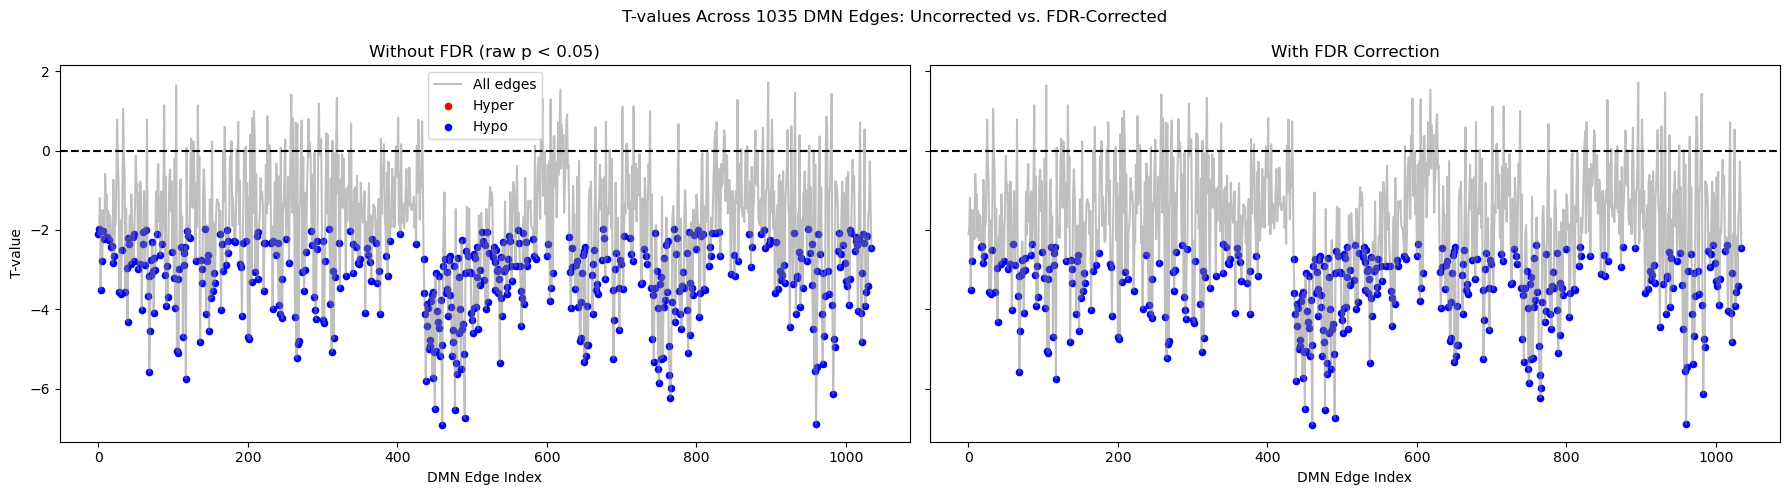

In [19]:
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# Assumes ASD_z, CONTROL_z already exist from the Fisher's z step
t_vals, p_val = ttest_ind(ASD_z, CONTROL_z)

# --- Uncorrected (raw p < 0.05) ---
hyper_mask_uncorrected = (t_vals > 0) & (p_val < 0.05)
hypo_mask_uncorrected  = (t_vals < 0) & (p_val < 0.05)

# --- FDR-corrected (Benjamini-Hochberg) ---
reject, p_fdr, _, _ = multipletests(p_val, alpha=0.05, method='fdr_bh')
hyper_mask_fdr = (t_vals > 0) & reject
hypo_mask_fdr  = (t_vals < 0) & reject

# --- Print comparison counts ---
print("=== UNCORRECTED (p < 0.05) ===")
print(f"Hyper: {hyper_mask_uncorrected.sum()}, Hypo: {hypo_mask_uncorrected.sum()}, "
      f"Total: {hyper_mask_uncorrected.sum() + hypo_mask_uncorrected.sum()} out of {len(p_val)}")

print("\n=== FDR-CORRECTED ===")
print(f"Hyper: {hyper_mask_fdr.sum()}, Hypo: {hypo_mask_fdr.sum()}, "
      f"Total: {hyper_mask_fdr.sum() + hypo_mask_fdr.sum()} out of {len(p_val)}")

# --- Side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

axes[0].plot(t_vals, color='gray', alpha=0.5, label='All edges')
axes[0].scatter(np.where(hyper_mask_uncorrected)[0], t_vals[hyper_mask_uncorrected],
                color='red', s=20, label='Hyper')
axes[0].scatter(np.where(hypo_mask_uncorrected)[0], t_vals[hypo_mask_uncorrected],
                color='blue', s=20, label='Hypo')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Without FDR (raw p < 0.05)")
axes[0].set_xlabel("DMN Edge Index")
axes[0].set_ylabel("T-value")
axes[0].legend()

axes[1].plot(t_vals, color='gray', alpha=0.5, label='All edges')
axes[1].scatter(np.where(hyper_mask_fdr)[0], t_vals[hyper_mask_fdr],
                color='red', s=20, label='Hyper')
axes[1].scatter(np.where(hypo_mask_fdr)[0], t_vals[hypo_mask_fdr],
                color='blue', s=20, label='Hypo')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("With FDR Correction")
axes[1].set_xlabel("DMN Edge Index")

plt.suptitle("T-values Across 1035 DMN Edges: Uncorrected vs. FDR-Corrected")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from scipy.stats import ttest_ind
from itertools import combinations

# Assumes ASD_z, CONTROL_z already exist from the Fisher's z step,
# and dmn_labels (46 DMN region names) already exists from the atlas cell

# --- t-test across all 1035 DMN edges ---
t_vals, p_vals = ttest_ind(ASD_z, CONTROL_z)

# --- Uncorrected masks (raw p < 0.05) ---
hyper_mask_uncorrected = (t_vals > 0) & (p_vals < 0.05)
hypo_mask_uncorrected  = (t_vals < 0) & (p_vals < 0.05)

print(f"[Uncorrected] Hyper: {hyper_mask_uncorrected.sum()}, Hypo: {hypo_mask_uncorrected.sum()}, "
      f"Total: {hyper_mask_uncorrected.sum() + hypo_mask_uncorrected.sum()} out of {len(p_vals)}")

# --- edge index -> region pair name lookup ---
# NOTE: assumes the 1035-length vectors are the upper triangle of the 46x46
# matrix in dmn_labels order (itertools.combinations order).
edge_labels = list(combinations(dmn_labels, 2))

# --- top 5 hyper edges (uncorrected) ---
hyper_idx = np.where(hyper_mask_uncorrected)[0]
top5_hyper = hyper_idx[np.argsort(t_vals[hyper_idx])[-5:]]
print("\nTop 5 hyper edges (uncorrected):")
for idx in top5_hyper:
    r1, r2 = edge_labels[idx]
    print(f"Edge {idx} ({r1} -- {r2}): t = {t_vals[idx]:.3f}, p = {p_vals[idx]:.5f}")

# --- top 5 hypo edges (uncorrected) ---
hypo_idx = np.where(hypo_mask_uncorrected)[0]
top5_hypo = hypo_idx[np.argsort(t_vals[hypo_idx])[:5]]
print("\nTop 5 hypo edges (uncorrected):")
for idx in top5_hypo:
    r1, r2 = edge_labels[idx]
    print(f"Edge {idx} ({r1} -- {r2}): t = {t_vals[idx]:.3f}, p = {p_vals[idx]:.5f}")

[Uncorrected] Hyper: 0, Hypo: 482, Total: 482 out of 1035

Top 5 hyper edges (uncorrected):

Top 5 hypo edges (uncorrected):
Edge 460 (7Networks_LH_Default_PFC_3 -- 7Networks_RH_Default_Temp_3): t = -6.903, p = 0.00000
Edge 960 (7Networks_RH_Default_Temp_4 -- 7Networks_RH_Default_PFCdPFCm_2): t = -6.890, p = 0.00000
Edge 490 (7Networks_LH_Default_PFC_4 -- 7Networks_RH_Default_Par_3): t = -6.741, p = 0.00000
Edge 477 (7Networks_LH_Default_PFC_4 -- 7Networks_LH_Default_PFC_8): t = -6.526, p = 0.00000
Edge 450 (7Networks_LH_Default_PFC_3 -- 7Networks_LH_Default_pCunPCC_1): t = -6.521, p = 0.00000


In [3]:
import numpy as np
from scipy.stats import ttest_ind
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Assumes ASD_z, CONTROL_z already exist from the Fisher's z step
X_all = np.vstack((ASD_z, CONTROL_z))
y = np.array([1]*ASD_z.shape[0] + [0]*CONTROL_z.shape[0])

seeds = [0, 1, 42, 123, 2024]

accuracies = []
f1_scores = []
n_hypo_list = []

for s in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=s, stratify=y
    )

    # t-test on training data only, uncorrected (raw p < 0.05)
    t_vals, p_val = ttest_ind(X_train[y_train == 1], X_train[y_train == 0])

    # Mask: keep ONLY hypoconnected edges (ASD < Control), no FDR correction
    hypo_mask = (t_vals < 0) & (p_val < 0.05)
    n_hypo_list.append(hypo_mask.sum())

    X_train_hypo = X_train[:, hypo_mask]
    X_test_hypo = X_test[:, hypo_mask]

    # SVM on hypo-only features
    pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="linear"))])
    pipe.fit(X_train_hypo, y_train)
    y_pred = pipe.predict(X_test_hypo)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"Seed {s}: {hypo_mask.sum()} hypo edges | Accuracy: {acc:.3f} | F1: {f1:.3f}")

print(f"\nMean accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Mean F1: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"Hypo feature count range across seeds: {min(n_hypo_list)}–{max(n_hypo_list)}")

Seed 0: 580 hypo edges | Accuracy: 0.503 | F1: 0.502
Seed 1: 564 hypo edges | Accuracy: 0.571 | F1: 0.571
Seed 42: 387 hypo edges | Accuracy: 0.577 | F1: 0.577
Seed 123: 350 hypo edges | Accuracy: 0.600 | F1: 0.600
Seed 2024: 524 hypo edges | Accuracy: 0.640 | F1: 0.640

Mean accuracy: 0.578 ± 0.045
Mean F1: 0.578 ± 0.045
Hypo feature count range across seeds: 350–580


In [23]:
import numpy as np
from scipy.stats import ttest_ind
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import loguniform

ASD = np.load("ASD_DMN_vectors.npy")
CONTROL = np.load("CONTROL_DMN_vectors.npy")

# Fisher's Z is applied here
ASD_z = np.arctanh(np.clip(ASD, -0.999999, 0.999999))
CONTROL_z = np.arctanh(np.clip(CONTROL, -0.999999, 0.999999))

X_all = np.vstack((ASD_z, CONTROL_z))
y = np.array([1]*ASD_z.shape[0] + [0]*CONTROL_z.shape[0])

# for achieving the average of the svm result, i used 5 random seeds 
seeds = [0, 1, 42, 123, 2024]


accuracies = []
f1_scores = []
n_features_list = []

for s in seeds:
    X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=s, stratify=y)

    t_vals, p_vals = ttest_ind(X_train[y_train == 1], X_train[y_train == 0])
    mask_uncorrected = (t_vals < 0) & (p_vals < 0.05)

    X_train_sel, X_test_sel = X_train[:, mask_uncorrected], X_test[:, mask_uncorrected]
    n_features_list.append(mask_uncorrected.sum())

    pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC())])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
    param_distributions = [
        {"svc__kernel": ["linear"], "svc__C": loguniform(1e-5, 1e2), "svc__class_weight": [None, "balanced"]},
        {"svc__kernel": ["rbf"], "svc__C": loguniform(1e-5, 1e2), "svc__gamma": loguniform(1e-5, 1e1), "svc__class_weight": [None, "balanced"]}
    ]
    search = RandomizedSearchCV(pipe, param_distributions, n_iter=100, scoring="f1_weighted",
                                 cv=cv, n_jobs=-1, random_state=s, verbose=0)
    search.fit(X_train_sel, y_train)
    y_pred = search.best_estimator_.predict(X_test_sel)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"Seed {s}: {mask_uncorrected.sum()} features | Accuracy: {acc:.3f} | F1: {f1:.3f}")

print(f"\nMean accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Mean F1: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"Feature count range across seeds: {min(n_features_list)}–{max(n_features_list)}")

Seed 0: 580 features | Accuracy: 0.577 | F1: 0.577
Seed 1: 564 features | Accuracy: 0.583 | F1: 0.579
Seed 42: 387 features | Accuracy: 0.634 | F1: 0.632
Seed 123: 350 features | Accuracy: 0.629 | F1: 0.607
Seed 2024: 524 features | Accuracy: 0.680 | F1: 0.666

Mean accuracy: 0.621 ± 0.038
Mean F1: 0.612 ± 0.033
Feature count range across seeds: 350–580


In [1]:
import numpy as np
import pandas as pd

# --------------------------------------------------------------------
# Load vectors and apply Fisher's Z
# --------------------------------------------------------------------
ASD_vectors = np.load("ASD_DMN_vectors.npy")
CONTROL_vectors = np.load("CONTROL_DMN_vectors.npy")
ASD_z = np.arctanh(np.clip(ASD_vectors, -0.999999, 0.999999))
CONTROL_z = np.arctanh(np.clip(CONTROL_vectors, -0.999999, 0.999999))

print(f"ASD_z shape: {ASD_z.shape}")
print(f"CONTROL_z shape: {CONTROL_z.shape}")

# --------------------------------------------------------------------
# Load metadata (row order matches vectors: numeric-sorted subj_0, subj_1, ...)
# --------------------------------------------------------------------
metadata = pd.read_csv("metadata_ASD_CONTROL_200ROI.csv")
asd_meta = metadata[metadata["group"] == "ASD"].reset_index(drop=True)
control_meta = metadata[metadata["group"] == "Control"].reset_index(drop=True)

assert len(asd_meta) == ASD_z.shape[0]
assert len(control_meta) == CONTROL_z.shape[0]
print(f"\nMetadata rows match vector rows: ASD ({len(asd_meta)}), Control ({len(control_meta)})")

# --------------------------------------------------------------------
# Build gender masks (SEX: 1 = Male, 2 = Female)
# --------------------------------------------------------------------
asd_male_mask = (asd_meta["SEX"] == 1).values
asd_female_mask = (asd_meta["SEX"] == 2).values
control_male_mask = (control_meta["SEX"] == 1).values
control_female_mask = (control_meta["SEX"] == 2).values

# --------------------------------------------------------------------
# Isolate Male/Female subsets from the connectivity vectors
# --------------------------------------------------------------------
ASD_z_male = ASD_z[asd_male_mask]
ASD_z_female = ASD_z[asd_female_mask]
CONTROL_z_male = CONTROL_z[control_male_mask]
CONTROL_z_female = CONTROL_z[control_female_mask]

print(f"\nASD Male vectors: {ASD_z_male.shape}, ASD Female vectors: {ASD_z_female.shape}")
print(f"Control Male vectors: {CONTROL_z_male.shape}, Control Female vectors: {CONTROL_z_female.shape}")

# --------------------------------------------------------------------
# Verify connection to metadata: spot-check a few subjects
# --------------------------------------------------------------------
print("\nSpot-check (first 3 Male ASD subjects, confirming SEX label matches):")
male_indices = np.where(asd_male_mask)[0][:3]
for idx in male_indices:
    print(f"  Row {idx}: file={asd_meta.loc[idx, 'file']}, SEX={asd_meta.loc[idx, 'SEX']}, "
          f"SEX_label={asd_meta.loc[idx, 'SEX_label']}, vector shape={ASD_z[idx].shape}")

print("\nSpot-check (first 3 Female ASD subjects):")
female_indices = np.where(asd_female_mask)[0][:3]
for idx in female_indices:
    print(f"  Row {idx}: file={asd_meta.loc[idx, 'file']}, SEX={asd_meta.loc[idx, 'SEX']}, "
          f"SEX_label={asd_meta.loc[idx, 'SEX_label']}, vector shape={ASD_z[idx].shape}")

ASD_z shape: (403, 1035)
CONTROL_z shape: (468, 1035)

Metadata rows match vector rows: ASD (403), Control (468)

ASD Male vectors: (349, 1035), ASD Female vectors: (54, 1035)
Control Male vectors: (378, 1035), Control Female vectors: (90, 1035)

Spot-check (first 3 Male ASD subjects, confirming SEX label matches):
  Row 0: file=TS_200ROI_ASD_simple/subj_0.npy, SEX=1, SEX_label=Male, vector shape=(1035,)
  Row 1: file=TS_200ROI_ASD_simple/subj_1.npy, SEX=1, SEX_label=Male, vector shape=(1035,)
  Row 3: file=TS_200ROI_ASD_simple/subj_3.npy, SEX=1, SEX_label=Male, vector shape=(1035,)

Spot-check (first 3 Female ASD subjects):
  Row 2: file=TS_200ROI_ASD_simple/subj_2.npy, SEX=2, SEX_label=Female, vector shape=(1035,)
  Row 15: file=TS_200ROI_ASD_simple/subj_15.npy, SEX=2, SEX_label=Female, vector shape=(1035,)
  Row 23: file=TS_200ROI_ASD_simple/subj_23.npy, SEX=2, SEX_label=Female, vector shape=(1035,)
